# Model Comparison

## Goal
Compare different prompt strategies on the same model.
Since we only have gemma3:12b locally, we compare:
- Zero-shot: no instructions, just question
- One-shot: one example before the question
- Chain-of-thought: ask the model to reason step by step

## Key Question
Does prompt engineering improve response quality?

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

## 1. Define Prompting Strategies

In [3]:
context = """
The Eiffel Tower was built between 1887 and 1889.
It is located in Paris, France, on the Champ de Mars.
The tower is 330 meters tall including its antenna.
It was designed by Gustave Eiffel and his engineering company.
The tower was originally intended to be a temporary structure
and was almost demolished in 1909.
It receives approximately 7 million visitors per year.
"""

questions = [
    {
        "question": "Where is the Eiffel Tower located?",
        "reference": "The Eiffel Tower is located in Paris, France, on the Champ de Mars."
    },
    {
        "question": "How tall is the Eiffel Tower?",
        "reference": "The Eiffel Tower is 330 meters tall including its antenna."
    },
    {
        "question": "When was the Eiffel Tower built?",
        "reference": "The Eiffel Tower was built between 1887 and 1889."
    },
]


def zero_shot(question: str, context: str) -> str:
    """No instructions — just question and context."""
    prompt = f"Context: {context}\nQuestion: {question}\nAnswer:"
    return call_model(prompt)


def one_shot(question: str, context: str) -> str:
    """One example before the actual question."""
    prompt = f"""Context: {context}

Example:
Question: Who designed the Eiffel Tower?
Answer: Gustave Eiffel and his engineering company.

Question: {question}
Answer:"""
    return call_model(prompt)


def chain_of_thought(question: str, context: str) -> str:
    """Ask model to reason step by step."""
    prompt = f"""Context: {context}

Question: {question}
Let's think step by step, then give a final answer:"""
    return call_model(prompt)


def call_model(prompt: str) -> str:
    """Call Ollama model with a prompt."""
    response = requests.post(
        "http://127.0.0.1:11434/api/chat",
        json={
            "model": "gemma3:12b",
            "messages": [{"role": "user", "content": prompt}],
            "stream": False
        },
        proxies={"http": None, "https": None}
    )
    return response.json()["message"]["content"]


print("Prompting strategies defined:")
print("- Zero-shot")
print("- One-shot")
print("- Chain-of-thought")

Prompting strategies defined:
- Zero-shot
- One-shot
- Chain-of-thought


## 2. Run Comparison

In [4]:
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

def score(response: str, reference: str) -> float:
    """Score response by semantic similarity to reference."""
    r_emb = embed_model.encode([response])
    ref_emb = embed_model.encode([reference])
    return float(cosine_similarity(r_emb, ref_emb)[0][0])


strategies = {
    "Zero-shot": zero_shot,
    "One-shot": one_shot,
    "Chain-of-thought": chain_of_thought
}

results = []
print("Running comparison...")

for qa in questions:
    for strategy_name, strategy_fn in strategies.items():
        response = strategy_fn(qa["question"], context)
        s = score(response, qa["reference"])
        results.append({
            "question": qa["question"][:40],
            "strategy": strategy_name,
            "response": response[:100],
            "score": s
        })
        print(f"\n[{strategy_name}] {qa["question"]}")
        print(f"Response: {response[:80]}...")
        print(f"Score: {s:.4f}")

df = pd.DataFrame(results)
print("\nAverage scores by strategy:")
print(df.groupby("strategy")["score"].mean().round(4))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Running comparison...

[Zero-shot] Where is the Eiffel Tower located?
Response: Paris, France, on the Champ de Mars....
Score: 0.6247

[One-shot] Where is the Eiffel Tower located?
Response: Paris, France, on the Champ de Mars....
Score: 0.6247

[Chain-of-thought] Where is the Eiffel Tower located?
Response: The text states the Eiffel Tower is located in Paris, France, on the Champ de Ma...
Score: 0.9691

[Zero-shot] How tall is the Eiffel Tower?
Response: 330 meters...
Score: 0.4941

[One-shot] How tall is the Eiffel Tower?
Response: The tower is 330 meters tall including its antenna....
Score: 0.8537

[Chain-of-thought] How tall is the Eiffel Tower?
Response: The text states "The tower is 330 meters tall including its antenna."

Final Ans...
Score: 0.8121

[Zero-shot] When was the Eiffel Tower built?
Response: The Eiffel Tower was built between 1887 and 1889....
Score: 1.0000

[One-shot] When was the Eiffel Tower built?
Response: Answer: Between 1887 and 1889....
Score: 0.4138

[Chai

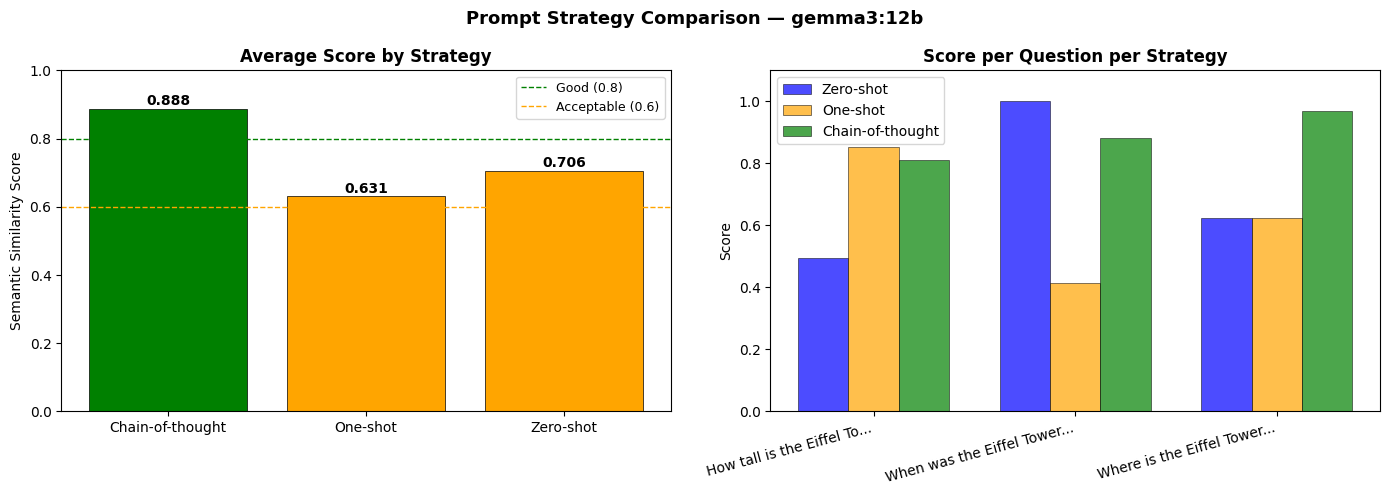

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Average score by strategy
avg_scores = df.groupby("strategy")["score"].mean()
colors = ["green" if s > 0.8 else "orange" if s > 0.6 else "red" for s in avg_scores]
bars = axes[0].bar(avg_scores.index, avg_scores.values, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Average Score by Strategy", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Semantic Similarity Score")
axes[0].set_ylim(0, 1)
axes[0].axhline(0.8, color="green", linestyle="--", linewidth=1, label="Good (0.8)")
axes[0].axhline(0.6, color="orange", linestyle="--", linewidth=1, label="Acceptable (0.6)")
axes[0].legend(fontsize=9)
for bar, score in zip(bars, avg_scores.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, score + 0.01,
                f'{score:.3f}', ha="center", fontweight="bold")

# Chart 2 — Score per question per strategy
pivot = df.pivot(index="question", columns="strategy", values="score")
x = np.arange(len(pivot))
width = 0.25
strategies_list = ["Zero-shot", "One-shot", "Chain-of-thought"]
strategy_colors = ["blue", "orange", "green"]

for i, (strategy, color) in enumerate(zip(strategies_list, strategy_colors)):
    axes[1].bar(x + i * width, pivot[strategy], width, label=strategy,
               color=color, alpha=0.7, edgecolor="black", linewidth=0.5)

axes[1].set_title("Score per Question per Strategy", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.1)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([q[:25] + "..." for q in pivot.index], rotation=15, ha="right")
axes[1].legend()

plt.suptitle("Prompt Strategy Comparison — gemma3:12b", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

## 4. Key Observations

| Strategy | Avg Score | Quality |
|----------|-----------|---------|
| Chain-of-thought | 0.888 | Good |
| Zero-shot | 0.706 | Acceptable |
| One-shot | 0.631 | Acceptable |

## Key Insight
Chain-of-thought consistently outperforms other strategies.
When the model explains its reasoning, it produces more complete answers
that match the reference more closely.

One-shot performed worse than zero-shot on one question —
the example confused the model into following the example format
rather than answering fully.

## Takeaway for Production
For factual QA tasks:
- Use chain-of-thought when answer quality matters most
- Zero-shot is a good baseline — simple and effective
- One-shot needs careful example selection

## Conclusion
Prompt engineering is not magic — it is systematic experimentation.
This notebook shows how to measure the impact of different strategies
rather than guessing which one works best.